In [1]:
import torch
import gc
from torch.utils.data import DataLoader
from models import get_model
from train import SpectrogramDataset, train_phase, test_model, ANIMALS, set_seeds
import pandas as pd

# Per riproducibilità
set_seeds(42)

# Parametri 
batch_size = 64
epochs = 30
patience = 5

In [2]:
# Dataset e dataLoader 
batch_size = 64

train_ds = SpectrogramDataset("train", max_samples=3000)
val_ds   = SpectrogramDataset("validation", max_samples=1000)
test_ds  = SpectrogramDataset("test", max_samples=1000)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


Loading 3000 samples from train... 

Ready: 3000 samples
Loading 1000 samples from validation... 

Ready: 1000 samples
Loading 1000 samples from test... 

Ready: 1000 samples


Training model1: LR=0.001, Epochs=30, Device=cuda


Epoch  1: Train=0.080 Val=0.086 Loss=2.485
   >>> New best model saved: 0.086


Epoch  2: Train=0.083 Val=0.086 Loss=2.485


Epoch  3: Train=0.087 Val=0.076 Loss=2.485


Epoch  4: Train=0.093 Val=0.076 Loss=2.485


Epoch  5: Train=0.093 Val=0.076 Loss=2.485


Epoch  6: Train=0.093 Val=0.076 Loss=2.486
   >>> Early stopping at epoch 6
Best validation accuracy: 0.086


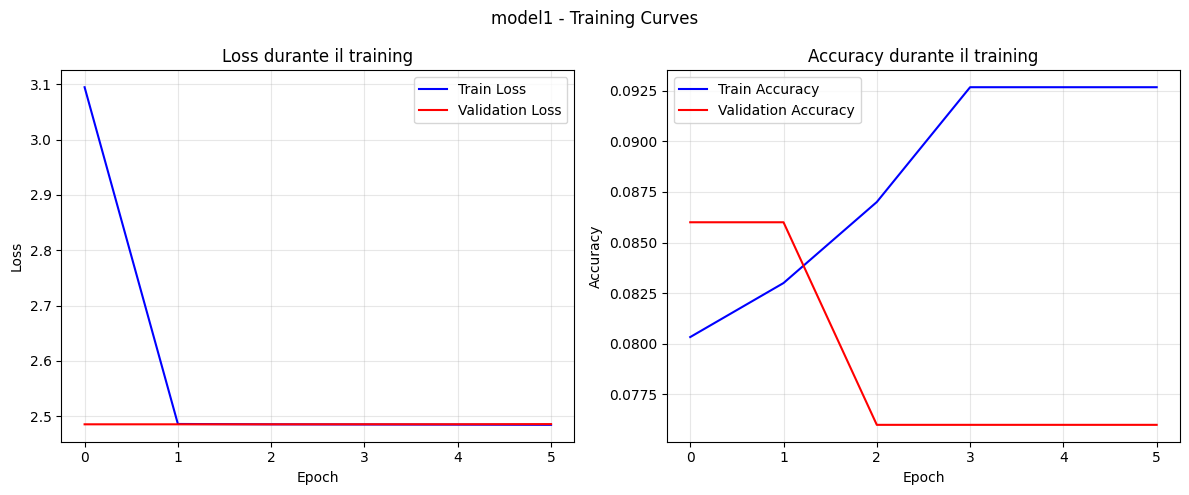

Model1 best validation accuracy: 0.086


Test Accuracy: 0.091
Per-class accuracy (worst to best):
   dog            : 0.000 (0/75)
   chirping_birds : 0.000 (0/82)
   rooster        : 0.000 (0/99)
   pig            : 0.000 (0/96)
   cow            : 0.000 (0/77)
   frog           : 0.000 (0/83)
   crickets       : 0.000 (0/81)
   crow           : 0.000 (0/71)
   hen            : 0.000 (0/90)
   sheep          : 0.000 (0/83)
   insects        : 0.000 (0/72)
   cat            : 1.000 (91/91)


<Figure size 1000x800 with 0 Axes>

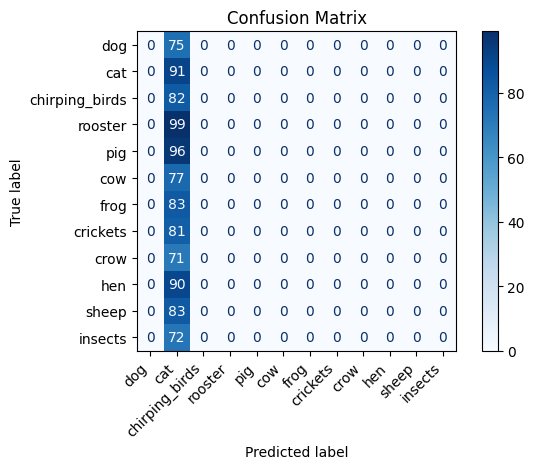

 Model1 test accuracy: 0.091


24674

In [3]:
# Model1
model = get_model("model1", num_classes=len(ANIMALS))

best_acc, *_ = train_phase(
    model, "model1", train_loader, val_loader,
    lr=1e-3, epochs=epochs, patience=patience
)

print(f"Model1 best validation accuracy: {best_acc:.3f}")

test_acc = test_model(model, "model1_best.pth", test_loader)
print(f" Model1 test accuracy: {test_acc:.3f}")

# Libera memoria
del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()


Training model1b: LR=0.001, Epochs=30, Device=cuda


Epoch  1: Train=0.082 Val=0.079 Loss=2.487
   >>> New best model saved: 0.079


Epoch  2: Train=0.083 Val=0.076 Loss=2.487


Epoch  3: Train=0.093 Val=0.076 Loss=2.487


Epoch  4: Train=0.093 Val=0.076 Loss=2.487


Epoch  5: Train=0.093 Val=0.076 Loss=2.486


Epoch  6: Train=0.093 Val=0.076 Loss=2.486
   >>> Early stopping at epoch 6
Best validation accuracy: 0.079


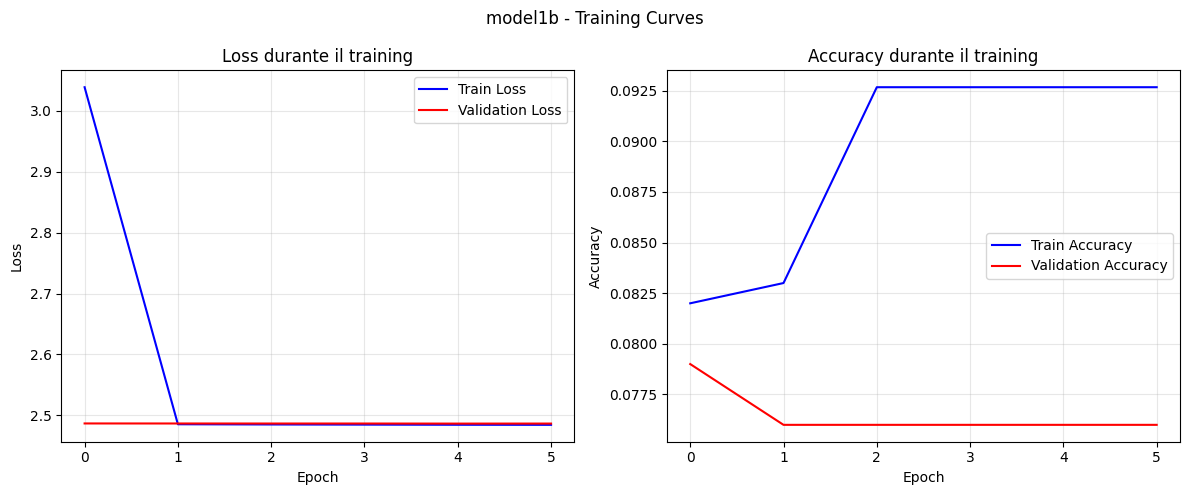

 Model 1b best val acc: 0.079


Test Accuracy: 0.090
Per-class accuracy (worst to best):
   dog            : 0.000 (0/75)
   cat            : 0.000 (0/91)
   chirping_birds : 0.000 (0/82)
   rooster        : 0.000 (0/99)
   pig            : 0.000 (0/96)
   cow            : 0.000 (0/77)
   frog           : 0.000 (0/83)
   crickets       : 0.000 (0/81)
   crow           : 0.000 (0/71)
   sheep          : 0.000 (0/83)
   insects        : 0.000 (0/72)
   hen            : 1.000 (90/90)


<Figure size 1000x800 with 0 Axes>

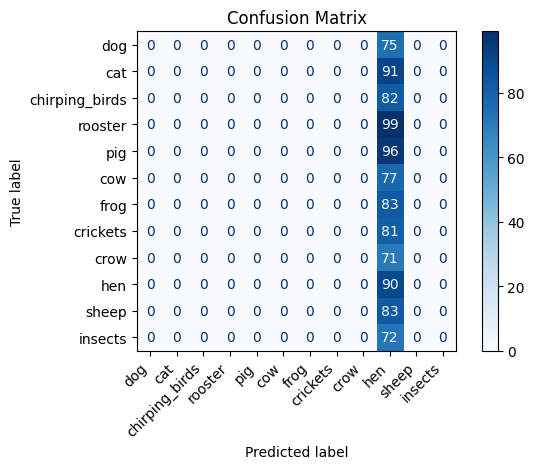

 Model1b test accuracy: 0.090


24641

In [4]:
#  Model 1b 
model = get_model("model1b", num_classes=len(ANIMALS))

best_acc, *_ = train_phase(
    model, "model1b", train_loader, val_loader,
    lr=1e-3, epochs=epochs, patience=patience
)

print(f" Model 1b best val acc: {best_acc:.3f}")

test_acc = test_model(model, "model1b_best.pth", test_loader)
print(f" Model1b test accuracy: {test_acc:.3f}")

# Libera memoria
del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

Training model1c: LR=0.001, Epochs=30, Device=cuda


Epoch  1: Train=0.076 Val=0.077 Loss=2.485
   >>> New best model saved: 0.077


Epoch  2: Train=0.080 Val=0.077 Loss=2.486


Epoch  3: Train=0.085 Val=0.079 Loss=2.484
   >>> New best model saved: 0.079


Epoch  4: Train=0.085 Val=0.077 Loss=2.485


...

Epoch 17: Train=0.809 Val=0.543 Loss=1.883


Epoch 18: Train=0.848 Val=0.530 Loss=1.852


Epoch 19: Train=0.864 Val=0.532 Loss=2.066


Epoch 20: Train=0.888 Val=0.519 Loss=2.046


Epoch 21: Train=0.899 Val=0.512 Loss=2.464
   >>> Early stopping at epoch 21
Best validation accuracy: 0.545


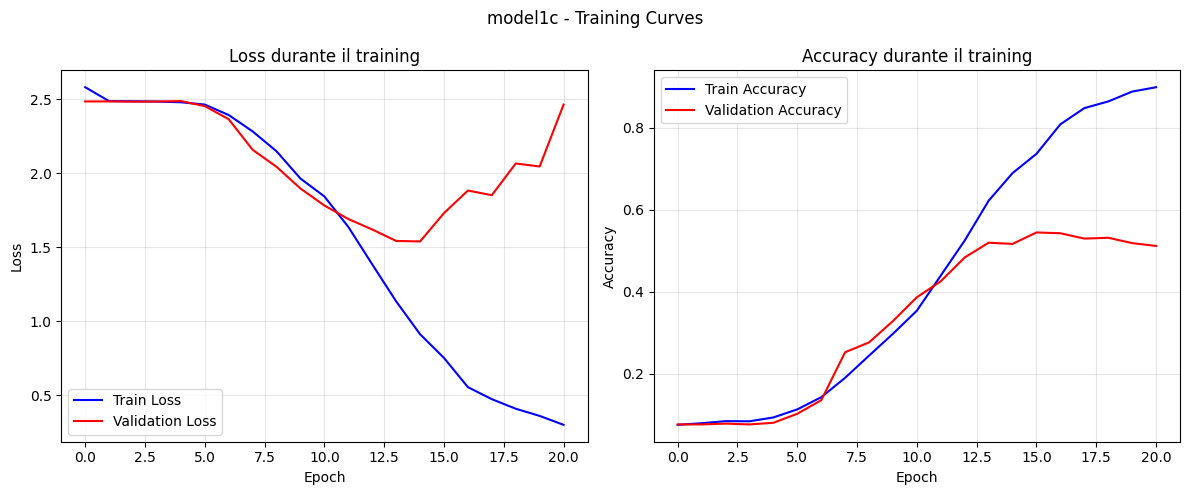

Model 1c best val acc: 0.545


Test Accuracy: 0.586
Per-class accuracy (worst to best):
   hen            : 0.322 (29/90)
   cat            : 0.374 (34/91)
   crickets       : 0.420 (34/81)
   chirping_birds : 0.451 (37/82)
   sheep          : 0.470 (39/83)
   crow           : 0.549 (39/71)
   pig            : 0.604 (58/96)
   dog            : 0.680 (51/75)
   rooster        : 0.707 (70/99)
   frog           : 0.783 (65/83)
   insects        : 0.819 (59/72)
   cow            : 0.922 (71/77)


<Figure size 1000x800 with 0 Axes>

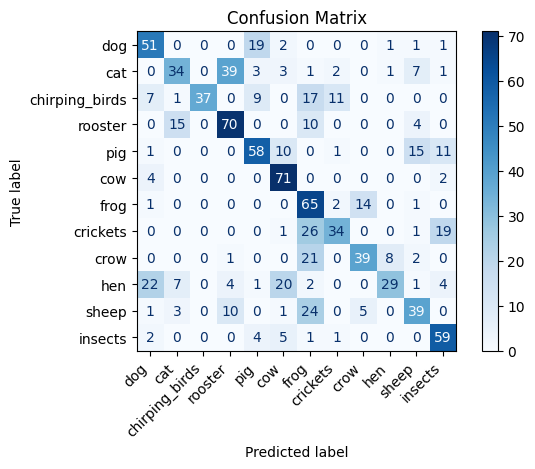

 Model1c test accuracy: 0.586


26076

In [5]:
# Model 1c 
model = get_model("model1c", num_classes=len(ANIMALS))

best_acc, *_ = train_phase(
    model, "model1c", train_loader, val_loader,
    lr=1e-3, epochs=epochs, patience=patience
)

print(f"Model 1c best val acc: {best_acc:.3f}")

test_acc = test_model(model, "model1c_best.pth", test_loader)
print(f" Model1c test accuracy: {test_acc:.3f}")

# Libera memoria
del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()


Training model2: LR=0.001, Epochs=30, Device=cuda


Epoch  1: Train=0.091 Val=0.136 Loss=2.431
   >>> New best model saved: 0.136


Epoch  2: Train=0.228 Val=0.289 Loss=1.986
   >>> New best model saved: 0.289


Epoch  3: Train=0.378 Val=0.420 Loss=1.642
   >>> New best model saved: 0.420


Epoch  4: Train=0.502 Val=0.521 Loss=1.533
   >>> New best model saved: 0.521


...

Epoch 18: Train=0.966 Val=0.620 Loss=2.542


Epoch 19: Train=0.970 Val=0.622 Loss=2.911


Epoch 20: Train=0.965 Val=0.619 Loss=2.314


Epoch 21: Train=0.976 Val=0.632 Loss=2.440


Epoch 22: Train=0.973 Val=0.612 Loss=2.430
   >>> Early stopping at epoch 22
Best validation accuracy: 0.640


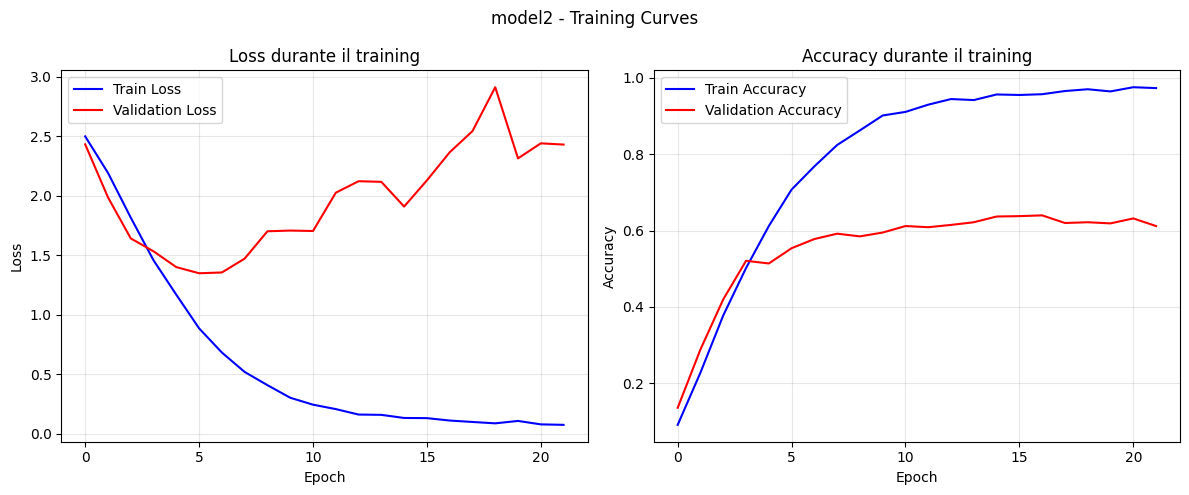

 Model2 best val acc: 0.640


Test Accuracy: 0.720
Per-class accuracy (worst to best):
   chirping_birds : 0.476 (39/82)
   cat            : 0.538 (49/91)
   sheep          : 0.578 (48/83)
   insects        : 0.583 (42/72)
   crickets       : 0.593 (48/81)
   pig            : 0.635 (61/96)
   frog           : 0.807 (67/83)
   rooster        : 0.828 (82/99)
   dog            : 0.867 (65/75)
   hen            : 0.889 (80/90)
   crow           : 0.930 (66/71)
   cow            : 0.948 (73/77)


<Figure size 1000x800 with 0 Axes>

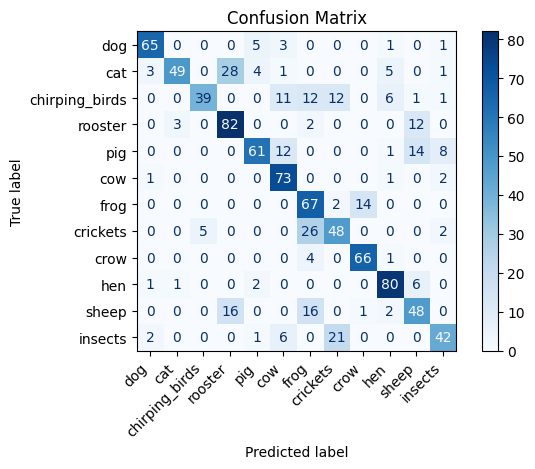

 Model2 test accuracy: 0.720


25645

In [6]:
# Model 2 
model = get_model("model2", num_classes=len(ANIMALS))

best_acc, *_ = train_phase(
    model, "model2", train_loader, val_loader,
    lr=1e-3, epochs=epochs, patience=patience
)

print(f" Model2 best val acc: {best_acc:.3f}")

test_acc = test_model(model, "model2_best.pth", test_loader)
print(f" Model2 test accuracy: {test_acc:.3f}")

# Libera memoria
del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()


In [ ]:

results = {
    "Model1 (BN=True, MaxPool, Drop=0.25)": 0.086, 
    "Model1b (BN=True, Stride, Drop=0.20)": 0.079,  
    "Model1c (BN=False, Stride, Drop=0.15)": 0.545,  
    "Model2 (BN=False, MaxPool, Drop=0.10)": 0.640,  
}

df_results = pd.DataFrame(results.items(), columns=["Model", "Test Accuracy"])
df_results = df_results.sort_values("Test Accuracy", ascending=False)
print(" RISULTATI FINALI")
display(df_results)

migliore = df_results.iloc[0]
print(f"\nModello migliore: {migliore['Model']}")
print(f"Test Accuracy: {migliore['Test Accuracy']:.4f}")

# Analisi miglioramenti
baseline_acc = results['Model1 (BN=True, MaxPool, Drop=0.25)']
improvement = migliore['Test Accuracy'] - baseline_acc
print(f"Miglioramento: {improvement:+.4f}")

if improvement > 0.02:
    print(f" Miglioramento significativo ottenuto!")
elif improvement > 0:
    print(f"Miglioramento modesto")
else:
    print(f" Nessun miglioramento significativo")

 RISULTATI FINALI


,Model,Test Accuracy
3,"Model2 (BN=False, MaxPool, Drop=0.10)",0.775
2,"Model1c (BN=False, Stride, Drop=0.15)",0.689
1,"Model1b (BN=True, Stride, Drop=0.20)",0.538
0,"Model1 (BN=True, MaxPool, Drop=0.25)",0.235



Modello migliore: Model2 (BN=False, MaxPool, Drop=0.10)
Test Accuracy: 0.7750
Miglioramento: +0.5400
 Miglioramento significativo ottenuto!


Loading 30000 samples from train... 

Ready: 30000 samples
Loading 10000 samples from validation... 

Ready: 10000 samples
Loading 10000 samples from test... 

Ready: 10000 samples
Train: 30000, Val: 10000, Test: 10000
Training model_final: LR=0.0001, Epochs=100, Device=cuda


Epoch  1: Train=0.299 Val=0.488 Loss=1.517
   >>> New best model saved: 0.488


...

Epoch 37: Train=0.993 Val=0.695 Loss=2.365


Epoch 38: Train=0.992 Val=0.709 Loss=2.390


Epoch 39: Train=0.992 Val=0.704 Loss=1.978


Epoch 40: Train=0.993 Val=0.692 Loss=2.296


Epoch 41: Train=0.993 Val=0.714 Loss=2.126
   >>> Early stopping at epoch 41
Best validation accuracy: 0.719


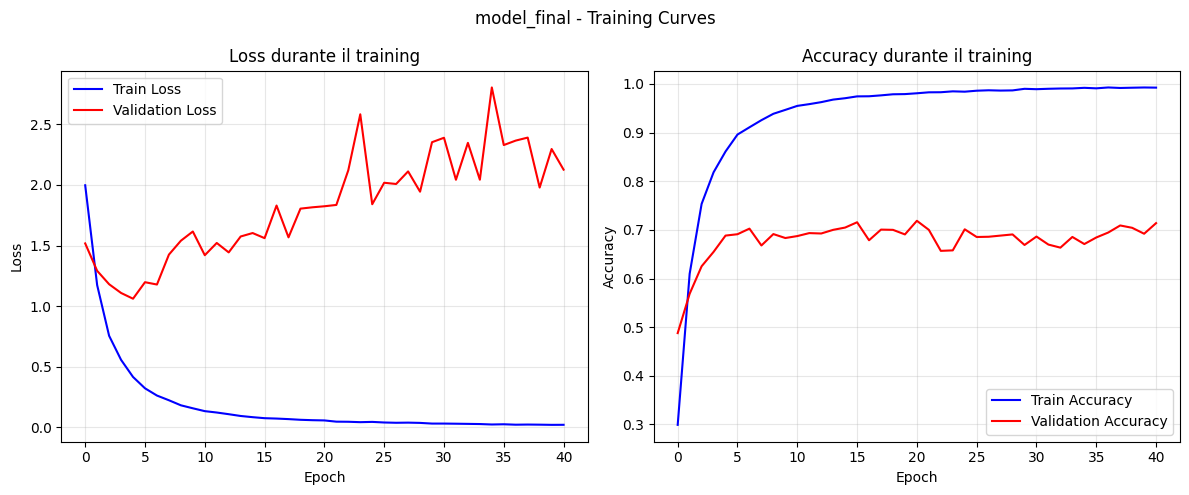

Test Accuracy: 0.805
Per-class accuracy (worst to best):
   chirping_birds : 0.515 (413/802)
   crickets       : 0.733 (633/864)
   cat            : 0.743 (617/830)
   crow           : 0.762 (640/840)
   hen            : 0.791 (673/851)
   sheep          : 0.807 (720/892)
   insects        : 0.816 (615/754)
   cow            : 0.818 (690/844)
   pig            : 0.819 (671/819)
   frog           : 0.915 (775/847)
   dog            : 0.961 (834/868)
   rooster        : 0.973 (768/789)


<Figure size 1000x800 with 0 Axes>

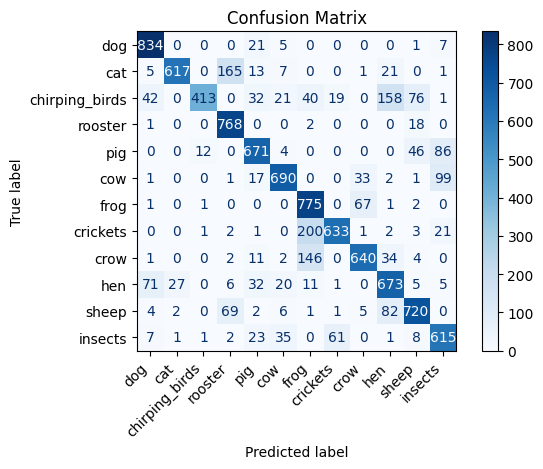

In [16]:
# Dataset completi
from models import Model2

train_full_ds = SpectrogramDataset('train')
val_full_ds = SpectrogramDataset('validation')
test_full_ds = SpectrogramDataset('test')

train_full_loader = DataLoader(train_full_ds, batch_size=64, shuffle=True, num_workers=4)
val_full_loader = DataLoader(val_full_ds, batch_size=64, shuffle=False, num_workers=4)
test_full_loader = DataLoader(test_full_ds, batch_size=64, shuffle=False, num_workers=4)

print(f"Train: {len(train_full_ds)}, Val: {len(val_full_ds)}, Test: {len(test_full_ds)}")

# Model2 architecture (parametri vincenti)
model_final = Model2()

# Training
final_acc, train_losses, val_losses, train_accs, val_accs = train_phase(
    model_final, "model_final", train_full_loader, val_full_loader, 
    lr=1e-4, epochs=100, patience=20
)

# Test finale
final_test_acc = test_model(model_final, "model_final_best.pth", test_full_loader)